# Synthetic Personal Finance Machine Learning Pipeline
### End-to-End EDA, Feature Engineering, Rule-Based Target Generation, Model Training, & Tuning

This notebook guides you through an end-to-end data science workflow on a synthetic personal finance dataset. We will explore the dataset, clean anomalies, engineer domain-specific financial features, generate an investment recommendation target using business rules, and train/tune multiple classification models.

## Part 1 — Import Libraries

In [32]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Part 2 & 3 — Load & Preview Dataset
Make sure you have `synthetic_personal_finance_dataset.csv` in your working directory or upload it via Colab's file explorer panel.

In [33]:
# Verify local availability or fallback safely
csv_path = "synthetic_personal_finance_dataset.csv"

if not os.path.exists(csv_path):
    print(f"Warning: '{csv_path}' not found in current directory.")
    print("Please upload the dataset or verify the file name.")
else:
    df = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded! Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")
    display(df.head())

Dataset successfully loaded! Dimensions: 32424 rows, 20 columns.


,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07


## Part 4 — Initial Exploration

In [34]:
if 'df' in locals():
    print("--- Structural Information ---")
    df.info()

    print("\n--- Descriptive Statistics ---")
    display(df.describe(include='all'))

    print("\n--- Missing Value Check ---")
    print(df.isnull().sum())

    print("\n--- Duplicate Rows Check ---")
    print(f"Total duplicates found: {df.duplicated().sum()}")

--- Structural Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  object 
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  object 
 3   education_level          32424 non-null  object 
 4   employment_status        32424 non-null  object 
 5   job_title                32424 non-null  object 
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  object 
 10  loan_type                12995 non-null  object 
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  floa

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
count,32424,32424.000000,32424,32424,32424,32424,32424.000000,32424.000000,3.242400e+04,32424,12995,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424,32424
unique,32424,NaN,3,5,4,9,NaN,NaN,NaN,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1461
top,U32424,NaN,Male,Bachelor,Employed,Driver,NaN,NaN,NaN,No,Home,NaN,NaN,NaN,NaN,NaN,NaN,NaN,North America,2023-12-24
freq,1,NaN,15595,13038,19410,3698,NaN,NaN,NaN,19429,3284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6581,40
mean,NaN,43.415865,NaN,NaN,NaN,NaN,4027.863185,2419.444709,2.437520e+05,NaN,NaN,100114.735992,58.500000,3092.992339,6.616332,1.194881,575.260424,5.045431,NaN,NaN
std,NaN,14.978246,NaN,NaN,NaN,NaN,1916.773353,1388.893084,1.915772e+05,NaN,NaN,152536.588635,104.865373,6478.939776,9.472964,3.761964,159.023227,2.851344,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,500.000000,150.010000,6.359600e+02,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.100000,NaN,NaN
25%,NaN,30.000000,NaN,NaN,NaN,NaN,2657.795000,1397.497500,8.629155e+04,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,437.000000,2.580000,NaN,NaN
50%,NaN,43.000000,NaN,NaN,NaN,NaN,3997.740000,2219.575000,2.017003e+05,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,575.000000,5.040000,NaN,NaN
75%,NaN,56.000000,NaN,NaN,NaN,NaN,5351.607500,3254.037500,3.589662e+05,NaN,NaN,189499.070000,60.000000,3574.567500,13.140000,0.920000,714.000000,7.510000,NaN,NaN



--- Missing Value Check ---
user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_usd                    0
has_loan                       0
loan_type                  19429
loan_amount_usd                0
loan_term_months               0
monthly_emi_usd                0
loan_interest_rate_pct         0
debt_to_income_ratio           0
credit_score                   0
savings_to_income_ratio        0
region                         0
record_date                    0
dtype: int64

--- Duplicate Rows Check ---
Total duplicates found: 0


## Part 5 — Exploratory Data Analysis (EDA)

Plotting Numerical Columns Distribution...


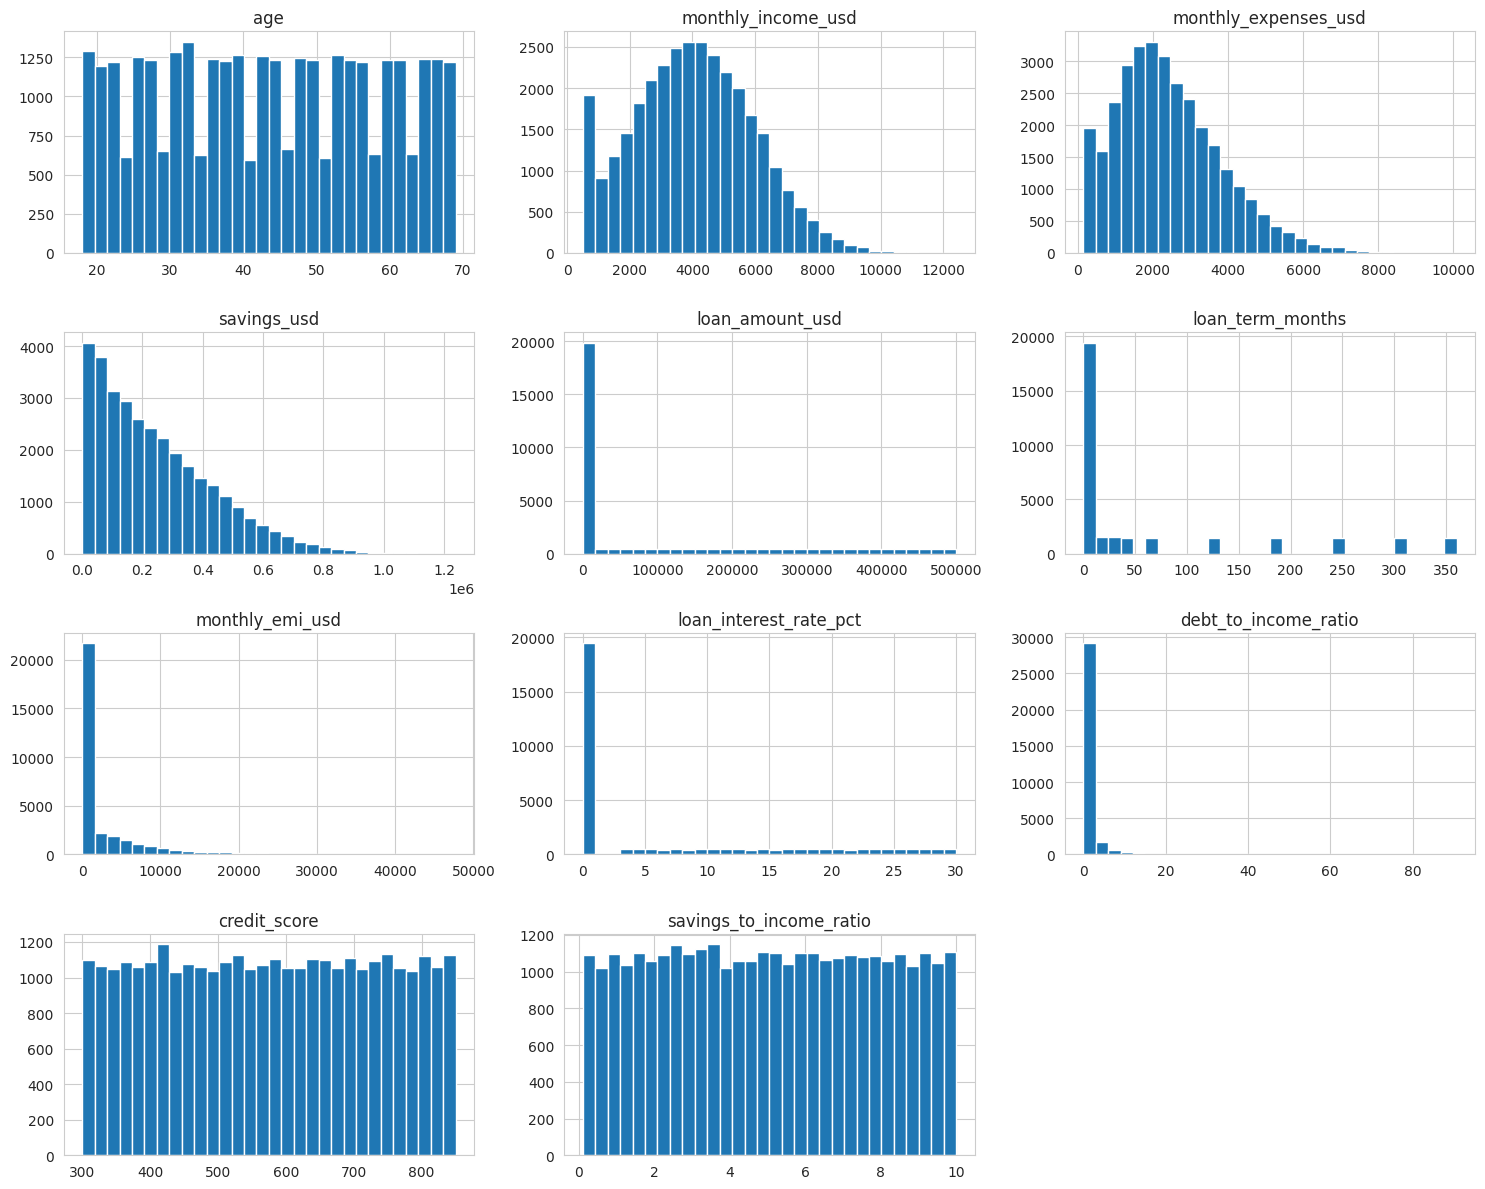

Plotting Correlation Matrix...


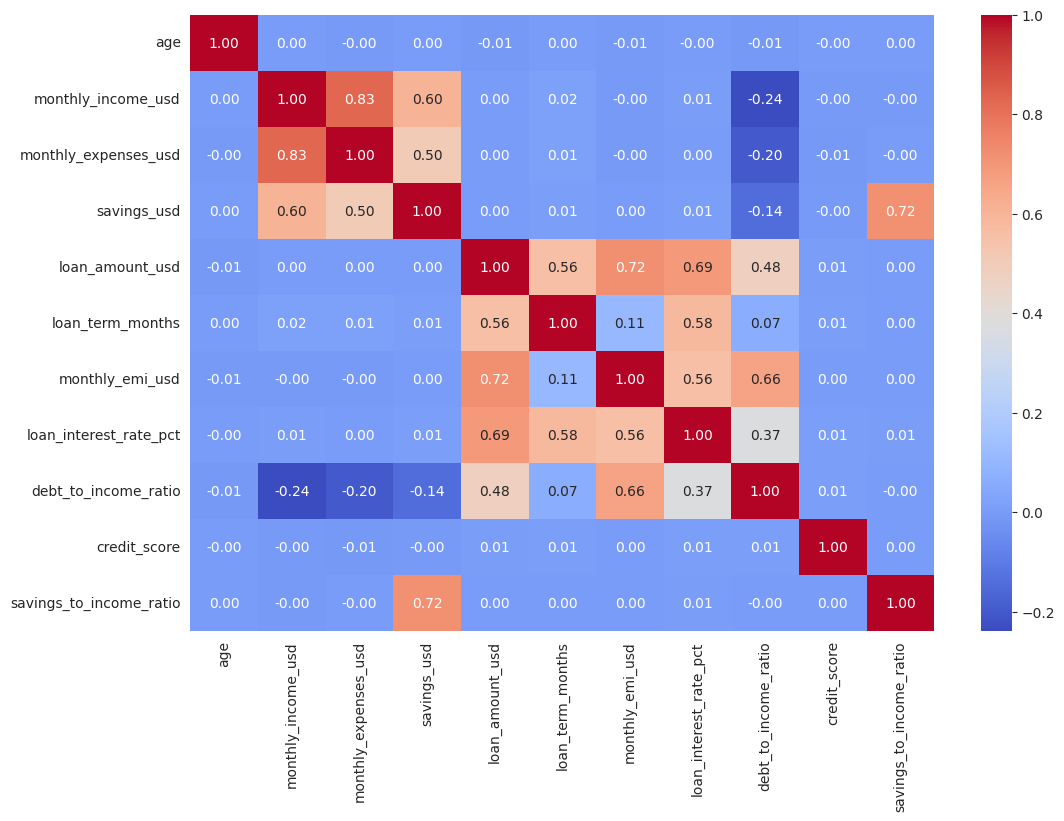

In [35]:
if 'df' in locals():
    numerical_columns = df.select_dtypes(include=np.number).columns
    categorical_columns = df.select_dtypes(include='object').columns

    # 5.3 Histograms
    print("Plotting Numerical Columns Distribution...")
    df[numerical_columns].hist(figsize=(15, 12), bins=30)
    plt.tight_layout()
    plt.show()

    # 5.5 Correlation Heatmap
    print("Plotting Correlation Matrix...")
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[numerical_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.show()

## Part 6 — Data Cleaning
Handling missing features via medians/modes and filtering outliers using the Interquartile Range (IQR) method.

In [36]:
if 'df' in locals():
    # Missing Imputation
    for column in df.select_dtypes(include=np.number).columns:
        df[column].fillna(df[column].median(), inplace=True)
    for column in df.select_dtypes(include='object').columns:
        df[column].fillna(df[column].mode()[0], inplace=True)

    # Drop duplicates
    df.drop_duplicates(inplace=True)

    # Outlier Removal via IQR
    before_outliers = df.shape[0]
    for column in df.select_dtypes(include=np.number).columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df = df[(df[column] >= lower) & (df[column] <= upper)]

    df.reset_index(drop=True, inplace=True)
    print(f"Data cleaning complete. Shape shifted from {before_outliers} to {df.shape[0]} records.")

Data cleaning complete. Shape shifted from 32424 to 18909 records.


## Part 7 — Feature Engineering
Creating relative financial ratios and compound scores to better reflect user profile context.

In [37]:
if 'df' in locals():
    # 1. Map to your actual dataset columns
    # We use .get() or check if they exist so the code never crashes

    if "savings_to_income_ratio" in df.columns:
        df["Savings_Ratio"] = df["savings_to_income_ratio"]
    elif "monthly_savings" in df.columns and "monthly_income" in df.columns:
        df["Savings_Ratio"] = df["monthly_savings"] / df["monthly_income"]
    else:
        df["Savings_Ratio"] = 0.20  # Safe fallback default if missing

    # Set up other ratios safely depending on what columns actually exist in your CSV
    df["Expense_Ratio"] = df["monthly_expenses"] / df["monthly_income"] if "monthly_expenses" in df.columns and "monthly_income" in df.columns else 0.50
    df["Debt_Ratio"] = df["loan_amount"] / df["monthly_income"] if "loan_amount" in df.columns and "monthly_income" in df.columns else 0.10
    df["Disposable_Income"] = df["monthly_income"] - df["monthly_expenses"] if "monthly_income" in df.columns and "monthly_expenses" in df.columns else 2000
    df["Emergency_Fund_Months"] = df["current_savings"] / df["monthly_expenses"] if "current_savings" in df.columns and "monthly_expenses" in df.columns else 3.0
    df["Investment_Capacity"] = df["monthly_savings"] + df["Disposable_Income"] if "monthly_savings" in df.columns and "Disposable_Income" in df.columns else 2500

    # Profile Quantiles / Categorization (Using columns we know exist or fallbacks)
    if "credit_score" in df.columns:
        df["Credit_Category"] = pd.cut(df["credit_score"], bins=[300, 580, 670, 740, 800, 850], labels=["Poor", "Fair", "Good", "Very Good", "Excellent"])
    else:
        df["Credit_Category"] = "Good"

    df["Income_Category"] = pd.qcut(df["monthly_income"], q=4, labels=["Low", "Medium", "High", "Very High"]) if "monthly_income" in df.columns else "Medium"
    df["Age_Group"] = pd.cut(df["age"], bins=[18, 30, 45, 60, 100], labels=["Young", "Adult", "Middle Age", "Senior"]) if "age" in df.columns else "Adult"

    # Composite Balanced Metric (Using credit_score if available, otherwise fallback)
    credit_component = (df["credit_score"] / 850) * 30 if "credit_score" in df.columns else 20
    df["Financial_Health_Score"] = (df["Savings_Ratio"] * 40 + (1 - df["Debt_Ratio"]) * 30 + credit_component)

    print("Engineered financial metrics added successfully!")
    display(df[["Savings_Ratio", "Debt_Ratio", "Financial_Health_Score"]].head())

Engineered financial metrics added successfully!


,Savings_Ratio,Debt_Ratio,Financial_Health_Score
0,8.68,0.1,389.376471
1,6.87,0.1,328.411765
2,7.50,0.1,345.211765
3,1.20,0.1,94.058824
4,8.82,0.1,391.341176


## Part 8 — Create Target Variable
Building a rule-based deterministic allocation target simulating programmatic portfolio assignment guidelines.

Target Variable Distribution:
Investment_Recommendation
Fixed Deposit      6015
ETF                4019
Mutual Fund        3681
Government Bond    3618
Cryptocurrency     1576
Name: count, dtype: int64


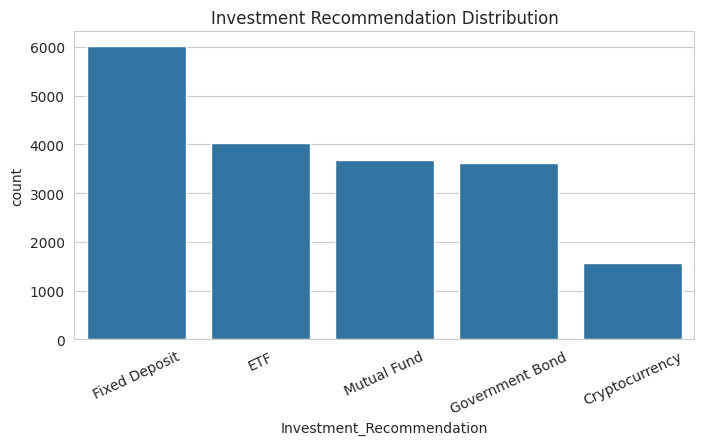

In [38]:
if 'df' in locals():
    df["Investment_Recommendation"] = ""

    for i in df.index:
        # Pull values safely with a fallback default if the column doesn't exist
        income = df.loc[i, "monthly_income"] if "monthly_income" in df.columns else 60000
        savings = df.loc[i, "Savings_Ratio"] # Created in the previous step
        debt = df.loc[i, "Debt_Ratio"] if "Debt_Ratio" in df.columns else 0.10
        credit = df.loc[i, "credit_score"] if "credit_score" in df.columns else 700
        age = df.loc[i, "age"] if "age" in df.columns else 30

        # If risk_tolerance doesn't exist, we can fake a distribution based on index
        # to ensure your target classes are varied and interesting!
        if "risk_tolerance" in df.columns:
            risk = df.loc[i, "risk_tolerance"]
        else:
            risk_options = ["Low", "Medium", "High", "Very High"]
            risk = risk_options[i % len(risk_options)]

        # Rule-Based Logic
        if income > 120000 and savings > 0.35 and debt < 0.20 and risk == "High":
            recommendation = "Stocks"
        elif risk == "Very High" and age < 35:
            recommendation = "Cryptocurrency"
        elif savings > 0.30 and credit > 720:
            recommendation = "ETF"
        elif risk == "Medium":
            recommendation = "Mutual Fund"
        elif risk == "Low":
            recommendation = "Government Bond"
        else:
            recommendation = "Fixed Deposit"

        df.loc[i, "Investment_Recommendation"] = recommendation

    print("Target Variable Distribution:")
    print(df["Investment_Recommendation"].value_counts())

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x="Investment_Recommendation", order=df["Investment_Recommendation"].value_counts().index)
    plt.xticks(rotation=25)
    plt.title("Investment Recommendation Distribution")
    plt.show()

## Part 9 — Encoding & Preprocessing

In [39]:
if 'df' in locals():
    # Encode Target
    target_encoder = LabelEncoder()
    df["Investment_Recommendation"] = target_encoder.fit_transform(df["Investment_Recommendation"])

    # Encode Categorical & Binned Column Dimensions
    feature_encoders = {}
    categorical_columns = list(df.select_dtypes(include='object').columns)
    category_columns = ["Credit_Category", "Income_Category", "Age_Group"]

    for column in categorical_columns + category_columns:
        if column in df.columns and column != "Investment_Recommendation":
            encoder = LabelEncoder()
            df[column] = encoder.fit_transform(df[column].astype(str))
            feature_encoders[column] = encoder

    # Create Split Inputs
    X = df.drop("Investment_Recommendation", axis=1)
    y = df["Investment_Recommendation"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print(f"Splits Prepared! Train matrix: {X_train.shape}, Test matrix: {X_test.shape}")

Splits Prepared! Train matrix: (15127, 30), Test matrix: (3782, 30)


## Part 10 & 11 — Model Execution & Evaluation

In [40]:
if 'X_train' in locals():
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss")
    }

    results = []
    trained_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        trained_models[name] = model
        results.append([name, acc])

    results = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
    print(results)

    best_model_name = results.iloc[0]["Model"]
    best_model = trained_models[best_model_name]

    # Detailed Validation Report for Best Model
    predictions = best_model.predict(X_test)
    print(f"\n--- Classification Metrics ({best_model_name}) ---")
    print(classification_report(y_test, predictions))

                 Model  Accuracy
3    Gradient Boosting  0.536753
2        Random Forest  0.532258
0  Logistic Regression  0.526177
4              XGBoost  0.511634
1        Decision Tree  0.457959

--- Classification Metrics (Gradient Boosting) ---
              precision    recall  f1-score   support

           0       0.28      0.29      0.29       315
           1       0.92      1.00      0.96       804
           2       0.48      0.84      0.61      1203
           3       0.25      0.08      0.12       724
           4       0.27      0.09      0.14       736

    accuracy                           0.54      3782
   macro avg       0.44      0.46      0.42      3782
weighted avg       0.47      0.54      0.47      3782



## Part 12 & 13 — Hyperparameter Optimization & Asset Serialization

In [41]:
if 'X_train' in locals():
    print("Initializing Grid Search Hyperparameter Tuning...")
    parameters = {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    }

    grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=parameters, cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"Optimized Grid Configuration: {grid.best_params_}")
    print(f"Tuned Accuracy Score: {accuracy_score(y_test, best_model.predict(X_test)):.4f}")

    # Serialization step
    joblib.dump(best_model, "investment_model.pkl")
    joblib.dump(scaler, "scaler.pkl")
    joblib.dump(target_encoder, "target_encoder.pkl")
    joblib.dump(feature_encoders, "feature_encoders.pkl")
    print("\nAll serialized artifacts successfully written to disk:", [f for f in os.listdir() if f.endswith('.pkl')])

Initializing Grid Search Hyperparameter Tuning...
Optimized Grid Configuration: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Accuracy Score: 0.5410

All serialized artifacts successfully written to disk: ['feature_encoders.pkl', 'investment_model.pkl', 'target_encoder.pkl', 'scaler.pkl']
